In [ ]:
import pandas as pd

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Dataloader

file_name = "/content/drive/My Drive/Colab Notebooks/Machine_Learning_Course/diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_name)

num_rows, num_cols = df.shape
print(f"Total rows: {num_rows}")
print(f"Total labels (columns): {num_cols}")

X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\nDataset split:")
print(f"Train set: {len(X_train)} rows")
print(f"Validation set: {len(X_val)} rows")
print(f"Test set: {len(X_test)} rows")

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

Total rows: 253680
Total labels (columns): 22

Dataset split:
Train set: 177576 rows
Validation set: 38052 rows
Test set: 38052 rows


### 1. Data Preprocessing for PyTorch CNN

First, we'll convert our pandas DataFrames into PyTorch tensors and reshape them appropriately for a 1D CNN. We'll also create `DataLoader` objects for efficient batch processing during training.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

X_train_tensor = X_train_tensor.unsqueeze(1)
X_val_tensor = X_val_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_classes = len(y.unique())
num_features = X_train.shape[1]

print(f"Number of classes: {num_classes}")
print(f"Number of features: {num_features}")

X_train_tensor shape: torch.Size([177576, 1, 21])
y_train_tensor shape: torch.Size([177576])
Number of classes: 3
Number of features: 21


### 2. CNN Model Definition

Here, we define the Convolutional Neural Network (CNN) architecture as specified: a 1D CNN to process the health indicators, followed by global average pooling, dropout for regularization, and a final fully connected layer for classification.

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)

        dummy_input = torch.randn(1, 1, num_features)
        x = self.pool1(self.relu1(self.conv1(dummy_input)))
        x = self.pool2(self.relu2(self.conv2(x)))
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.global_avg_pool(x)
        x = x.squeeze(2)
        x = self.dropout(x)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = CNN(num_features, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

Using device: cuda
CNN(
  (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


### 3. Model Training

We will now train the CNN model using the training and validation datasets. We'll track the loss and accuracy for both sets over epochs to monitor training progress and detect overfitting.

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, '+
              f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}')

    return history

num_epochs = 20
training_history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)

Epoch 1/20 - Train Loss: 0.4524, Train Acc: 0.8421, Val Loss: 0.4135, Val Acc: 0.8430
Epoch 2/20 - Train Loss: 0.4241, Train Acc: 0.8432, Val Loss: 0.4089, Val Acc: 0.8443
Epoch 3/20 - Train Loss: 0.4179, Train Acc: 0.8441, Val Loss: 0.4044, Val Acc: 0.8457
Epoch 4/20 - Train Loss: 0.4149, Train Acc: 0.8441, Val Loss: 0.4040, Val Acc: 0.8452
Epoch 5/20 - Train Loss: 0.4130, Train Acc: 0.8444, Val Loss: 0.4034, Val Acc: 0.8453
Epoch 6/20 - Train Loss: 0.4114, Train Acc: 0.8448, Val Loss: 0.4048, Val Acc: 0.8441
Epoch 7/20 - Train Loss: 0.4096, Train Acc: 0.8452, Val Loss: 0.4063, Val Acc: 0.8468
Epoch 8/20 - Train Loss: 0.4097, Train Acc: 0.8452, Val Loss: 0.4009, Val Acc: 0.8461
Epoch 9/20 - Train Loss: 0.4083, Train Acc: 0.8451, Val Loss: 0.4020, Val Acc: 0.8458
Epoch 10/20 - Train Loss: 0.4070, Train Acc: 0.8449, Val Loss: 0.4014, Val Acc: 0.8448
Epoch 11/20 - Train Loss: 0.4068, Train Acc: 0.8459, Val Loss: 0.3994, Val Acc: 0.8467
Epoch 12/20 - Train Loss: 0.4065, Train Acc: 0.8456,

### 4. Model Evaluation

After training, we evaluate the model's performance on the unseen test set. We'll compute accuracy, precision, recall, F1-score, and the confusion matrix to get a comprehensive understanding of the model's classification abilities.

In [ ]:
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

test_preds, test_labels = evaluate_model(model, test_loader, device)

accuracy = accuracy_score(test_labels, test_preds)
precision, recall, f1_score, _ = precision_recall_fscore_support(test_labels, test_preds, average='weighted', zero_division=0)
conf_matrix = confusion_matrix(test_labels, test_preds)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1_score:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)


Test Accuracy: 0.8483
Test Precision: 0.8018
Test Recall: 0.8483
Test F1-Score: 0.8046

Confusion Matrix:
[[31503     0   552]
 [  640     0    55]
 [ 4527     0   775]]


### 5. Visualization for Presentation

These plots will help visualize the model's training progress and performance on the test set, which are great for presentations.

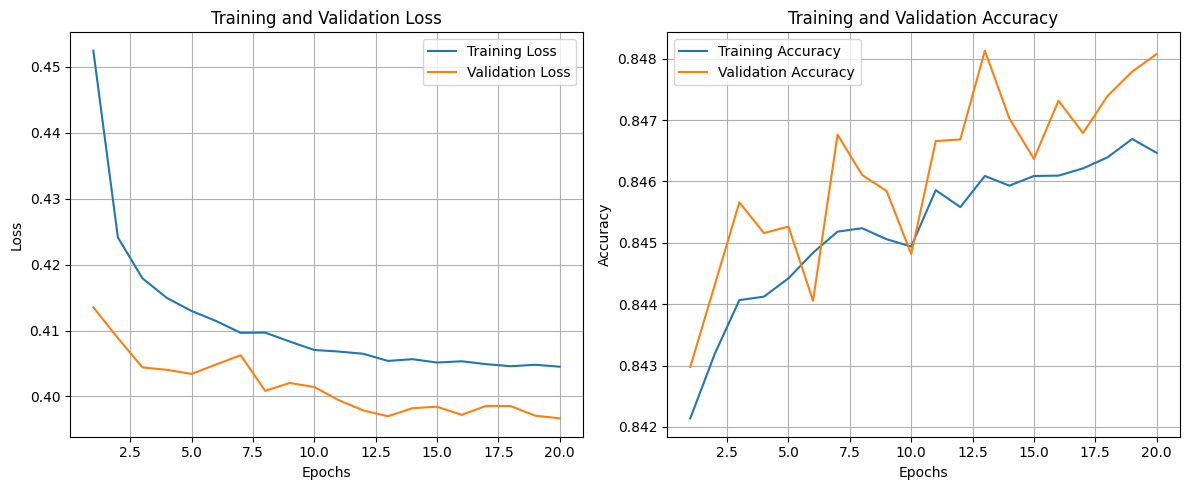

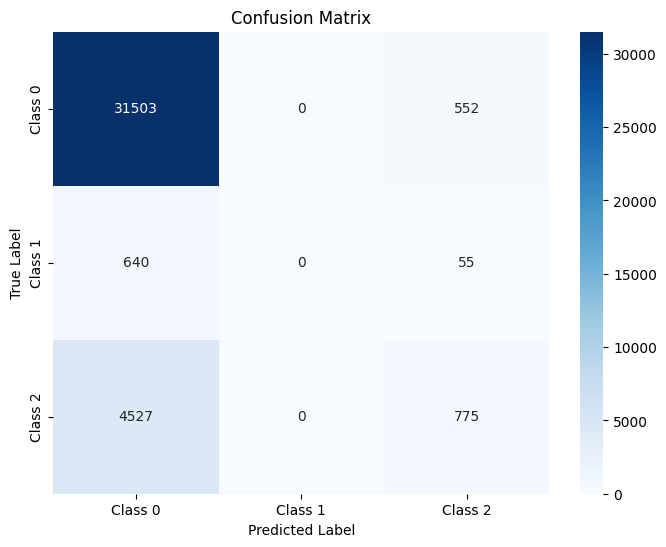

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_history['train_loss'], label='Training Loss')
plt.plot(epochs, training_history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, training_history['train_acc'], label='Training Accuracy')
plt.plot(epochs, training_history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in range(num_classes)],
            yticklabels=[f'Class {i}' for i in range(num_classes)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)

        dummy_input = torch.randn(1, 1, num_features)
        x = self.pool1(self.relu1(self.conv1(dummy_input)))
        x = self.pool2(self.relu2(self.conv2(x)))
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.global_avg_pool(x)
        x = x.squeeze(2)
        x = self.dropout(x)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = CNN(num_features, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

Using device: cuda
CNN(
  (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, '+
              f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}')

    return history

num_epochs = 20
training_history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)

Epoch 1/20 - Train Loss: 0.4445, Train Acc: 0.8420, Val Loss: 0.4132, Val Acc: 0.8438
Epoch 2/20 - Train Loss: 0.4214, Train Acc: 0.8433, Val Loss: 0.4129, Val Acc: 0.8435
Epoch 3/20 - Train Loss: 0.4175, Train Acc: 0.8439, Val Loss: 0.4077, Val Acc: 0.8451
Epoch 4/20 - Train Loss: 0.4144, Train Acc: 0.8442, Val Loss: 0.4050, Val Acc: 0.8440
Epoch 5/20 - Train Loss: 0.4117, Train Acc: 0.8439, Val Loss: 0.4035, Val Acc: 0.8444
Epoch 6/20 - Train Loss: 0.4101, Train Acc: 0.8446, Val Loss: 0.4043, Val Acc: 0.8441
Epoch 7/20 - Train Loss: 0.4094, Train Acc: 0.8448, Val Loss: 0.4045, Val Acc: 0.8453
Epoch 8/20 - Train Loss: 0.4088, Train Acc: 0.8452, Val Loss: 0.4008, Val Acc: 0.8460
Epoch 9/20 - Train Loss: 0.4084, Train Acc: 0.8451, Val Loss: 0.4016, Val Acc: 0.8452
Epoch 10/20 - Train Loss: 0.4071, Train Acc: 0.8458, Val Loss: 0.3999, Val Acc: 0.8464
Epoch 11/20 - Train Loss: 0.4069, Train Acc: 0.8454, Val Loss: 0.4005, Val Acc: 0.8460
Epoch 12/20 - Train Loss: 0.4068, Train Acc: 0.8454,

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_history['train_loss'], label='Training Loss')
plt.plot(epochs, training_history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, training_history['train_acc'], label='Training Accuracy')
plt.plot(epochs, training_history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in range(num_classes)],
            yticklabels=[f'Class {i}' for i in range(num_classes)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

test_preds, test_labels = evaluate_model(model, test_loader, device)

accuracy = accuracy_score(test_labels, test_preds)
precision, recall, f1_score, _ = precision_recall_fscore_support(test_labels, test_preds, average='weighted', zero_division=0)
conf_matrix = confusion_matrix(test_labels, test_preds)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1_score:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)


Test Accuracy: 0.8474
Test Precision: 0.8048
Test Recall: 0.8474
Test F1-Score: 0.7915

Confusion Matrix:
[[31834     0   221]
 [  674     0    21]
 [ 4890     0   412]]


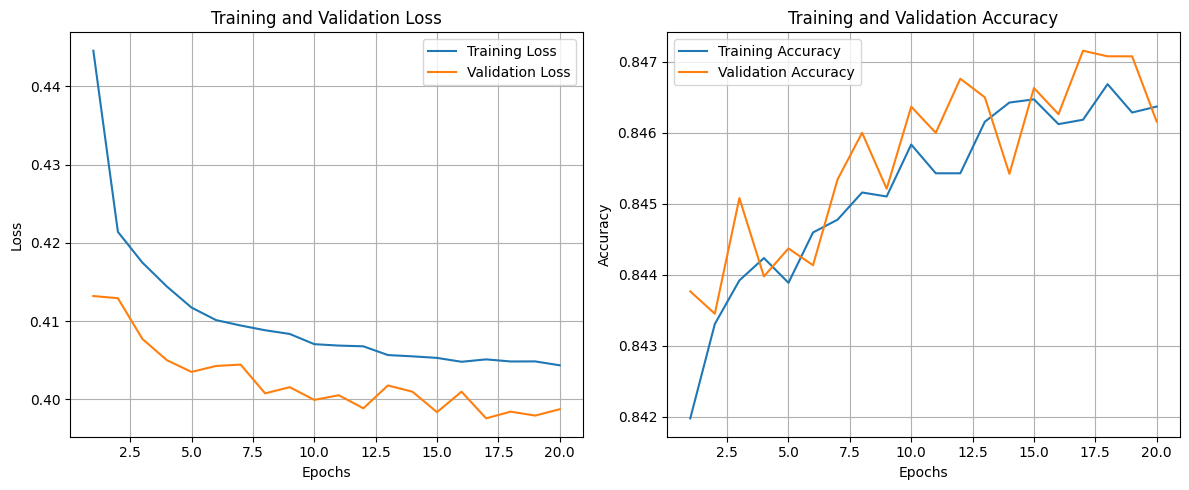

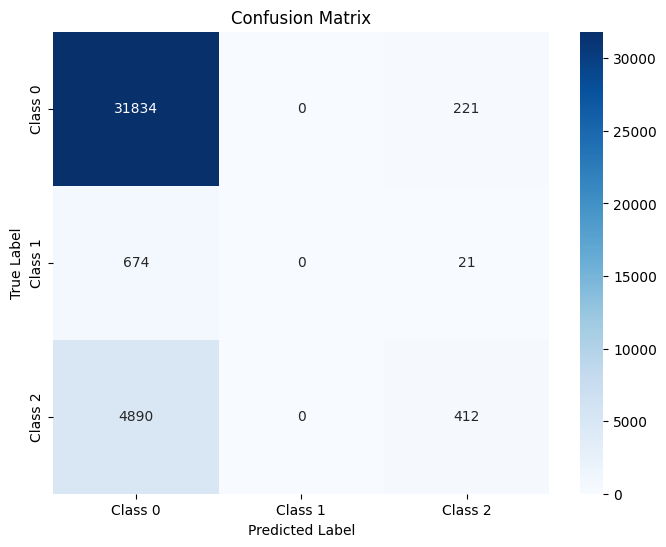

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_history['train_loss'], label='Training Loss')
plt.plot(epochs, training_history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, training_history['train_acc'], label='Training Accuracy')
plt.plot(epochs, training_history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in range(num_classes)],
            yticklabels=[f'Class {i}' for i in range(num_classes)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()